<a class="anchor" id="lab-task-1"></a>
<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px"><strong style="color:#FF5555">1. Lab Task: </strong> 
    <ol>       
        <li>Complete the <strong>Kafka Consumer</strong> in the file. Here you are required address the following requirements:
       <ul>
           <li>Read the incoming data stream in the topic <strong>clickstream</strong></li>
           <li>Generate a real-time visualization showing <strong>total number of clicks and impressions for every instance received</strong></li>
            </ul>
    </ol>
</div>



/var/folders/9l/03xt3yvj2gg2s7lfps5hf6gh0000gn/T/ipykernel_78859/1731442881.py:10: DeprecationWarning: value_deserializer does not implement kafka.serializer.Deserializer
  consumer = KafkaConsumer(


Waiting for messages...
Batch 1: Clicks=0, Impressions=55
Batch 2: Clicks=0, Impressions=40
Batch 3: Clicks=2, Impressions=49
Batch 4: Clicks=2, Impressions=25
Batch 5: Clicks=0, Impressions=54
Batch 6: Clicks=2, Impressions=44
Batch 7: Clicks=0, Impressions=33
Batch 8: Clicks=1, Impressions=32
Batch 9: Clicks=1, Impressions=31
Batch 10: Clicks=2, Impressions=26


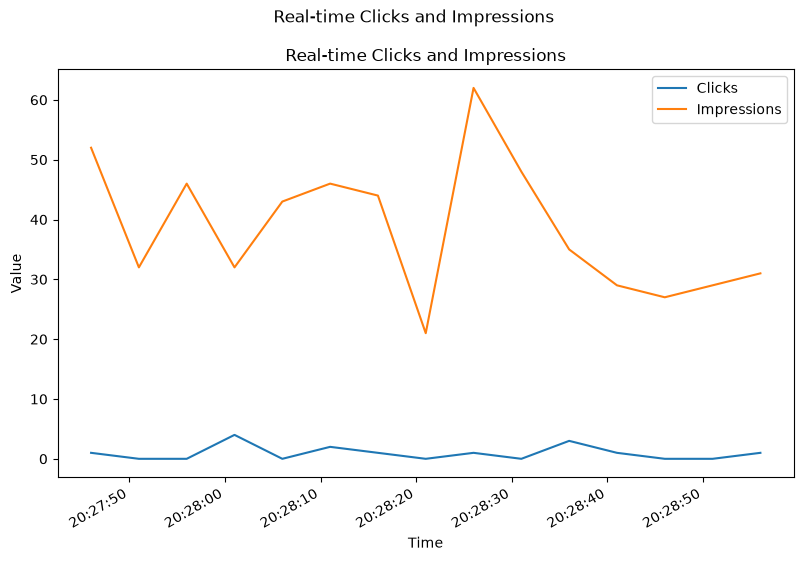

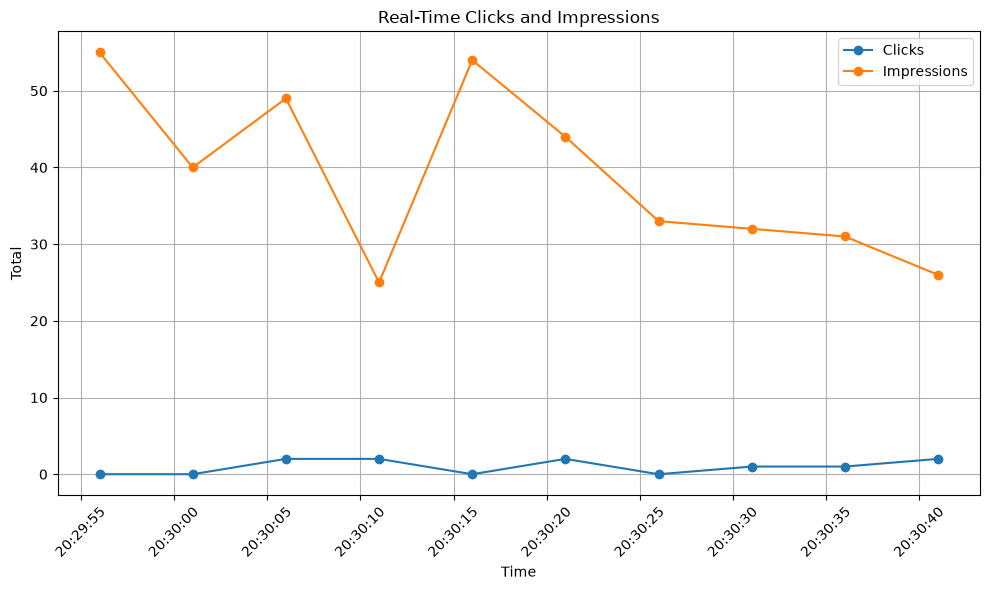

In [2]:
from kafka import KafkaConsumer
import datetime as dt
import matplotlib.pyplot as plt
from json import loads

%matplotlib inline

topic = 'clickstream'

consumer = KafkaConsumer(
    topic,
    bootstrap_servers=['localhost:9092'],
    auto_offset_reset='latest',
    consumer_timeout_ms=10000,
    value_deserializer=lambda x: loads(x.decode('utf-8'))
)

x = []
clicks = []
impressions = []

print("Waiting for messages...")

for i, message in enumerate(consumer):
    data = message.value

    timestamp = data[0]['ts']
    total_clicks = sum(int(row['Clicks']) for row in data)
    total_impressions = sum(int(row['Impressions']) for row in data)

    x.append(dt.datetime.fromtimestamp(timestamp))
    clicks.append(total_clicks)
    impressions.append(total_impressions)

    print(
        f"Batch {i+1}: "
        f"Clicks={total_clicks}, "
        f"Impressions={total_impressions}"
    )

    if i >= 9:
        break

consumer.close()

plt.figure(figsize=(10, 6))
plt.plot(x, clicks, marker='o', label='Clicks')
plt.plot(x, impressions, marker='o', label='Impressions')

plt.xlabel('Time')
plt.ylabel('Total')
plt.title('Real-Time Clicks and Impressions')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
!pip install ipympl